In [5]:
pip install opencv-contrib-python==4.5.5.64


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
import cv2
print(hasattr(cv2, 'saliency'))
# Should be True

# Or test the actual instantiation:
cv2.saliency.StaticSaliencySpectralResidual_create()
# Should run with no errors


True


<saliency_StaticSaliencySpectralResidual 0x7ff5c5d30cf0>

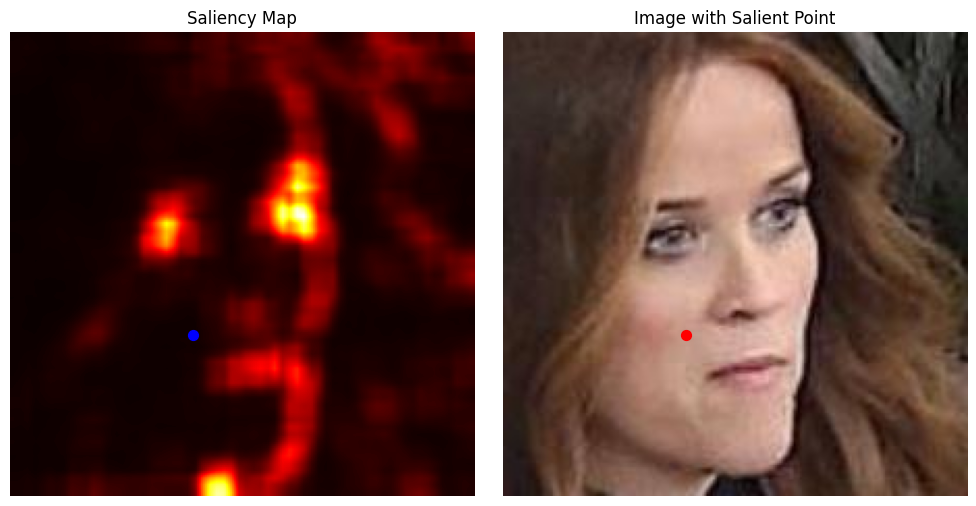

In [30]:
import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image

def getPoints(numPoints, prob_arr, threshold=0.20):
    crop_size = 0
    flat = prob_arr.reshape(-1)
    
    y_thresh = max(crop_size // 2, int(threshold * prob_arr.shape[0]))
    x_thresh = max(crop_size // 2, int(threshold * prob_arr.shape[0]))
    mask = np.zeros_like(prob_arr)
    mask[y_thresh:-y_thresh, x_thresh:-x_thresh] = 1
    mask = mask.reshape(-1)
    
    probs = flat * mask
    probs_sum = probs.sum()
    if probs_sum > 0:
        probs /= probs_sum
        idx = np.random.choice(flat.shape[0], numPoints, p=probs)
        ys, xs = np.unravel_index(idx, prob_arr.shape)
        return np.stack([ys, xs], axis=0)
    else:
        # fallback to uniform
        idx = np.random.choice(flat.shape[0], numPoints)
        ys, xs = np.unravel_index(idx, prob_arr.shape)
        return np.stack([ys, xs], axis=0)

def SaliencePoints(data):
    # Accepts C×H×W torch tensor or image array
    if isinstance(data, torch.Tensor):
        img = data.cpu().numpy().transpose(1, 2, 0)  # C×H×W → H×W×C
    else:
        img = data

    img = np.uint8(img)  # Ensure type
    cv2_img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)  # Convert to OpenCV BGR

    saliency = cv2.saliency.StaticSaliencySpectralResidual_create()
    success, sal_map = saliency.computeSaliency(cv2_img)

    if not success:
        raise RuntimeError("Saliency computation failed")

    pts = getPoints(1, sal_map)
    return int(pts[0, 0]), int(pts[1, 0]), sal_map

def visualize_salience_point(image_path):
    # Load image and convert to RGB numpy array
    img = Image.open(image_path).convert("RGB")
    img_np = np.array(img)

    x, y, saliency_map = SaliencePoints(img_np)

    # Plot saliency map + overlaid point
    fig, axs = plt.subplots(1, 2, figsize=(10, 5))

    axs[0].imshow(saliency_map, cmap='hot')
    axs[0].scatter(x, y, color='blue', s=50, label='Most Salient')
    axs[0].set_title("Saliency Map")
    axs[0].axis('off')

    axs[1].imshow(img_np)
    axs[1].scatter(x, y, color='red', s=50, label='Most Salient')
    axs[1].set_title("Image with Salient Point")
    axs[1].axis('off')

    plt.tight_layout()
    plt.show()

# Example usage
visualize_salience_point("images//100.jpg")
